In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. ENVIRONMENT & IMPORTS
# Install required packages first
!pip install -q tensorflow scikit-learn matplotlib pandas pillow tqdm tf-keras-vis

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
from PIL import Image
import imghdr
import IPython.display as disp

# Set seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Check TensorFlow version and GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)
print("GPU Devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: True
GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# 2. DATASET CLEANING
# This section ensures all images are valid and converts problematic formats to JPG

DATA_DIR = "/content/drive/MyDrive/AI Sem6/Coursework/Assignment2/Vehicles"
CONVERT_TO_JPG = True     # Set False if you just want to delete bad files

def clean_dataset():
    bad_files = []
    for root, _, files in os.walk(DATA_DIR):
        for f in tqdm(files, desc=os.path.basename(root)):
            fp = os.path.join(root, f)
            # Quick header sniff
            if imghdr.what(fp) is None:
                bad_files.append(fp)
                continue
            # Full TF decode test to catch corrupt JPEGs
            try:
                _ = tf.io.decode_image(tf.io.read_file(fp), channels=3)
            except tf.errors.InvalidArgumentError:
                bad_files.append(fp)

    print(f"Found {len(bad_files)} unusable files")
    for bf in bad_files[:5]:
        print("Invalid", bf)

    # Fix or remove problematic files
    for bf in bad_files:
        if CONVERT_TO_JPG:                         # try conversion
            try:
                img = Image.open(bf).convert("RGB")
                new_fp = os.path.splitext(bf)[0] + ".jpg"
                img.save(new_fp, "JPEG", quality=95)
                os.remove(bf)
            except Exception as e:
                print("Conversion failed – deleting", bf, ":", e)
                os.remove(bf)
        else:
            os.remove(bf)
    print("Cleaning done")

clean_dataset()

Vehicles: 0it [00:00, ?it/s]
Bikes: 100%|██████████| 800/800 [00:16<00:00, 47.37it/s] 

Found 0 unusable files
Cleaning done


Found 5569 files belonging to 7 classes.
Using 4456 files for training.
Found 5569 files belonging to 7 classes.
Using 1113 files for validation.
Classes: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']

Dataset Analysis:
Total images: 5571
Number of classes: 7

Class distribution:
  - Auto Rickshaws: 799 images (14.3%)
  - Bikes: 800 images (14.4%)
  - Cars: 790 images (14.2%)
  - Motorcycles: 800 images (14.4%)
  - Planes: 786 images (14.1%)
  - Ships: 798 images (14.3%)
  - Trains: 798 images (14.3%)


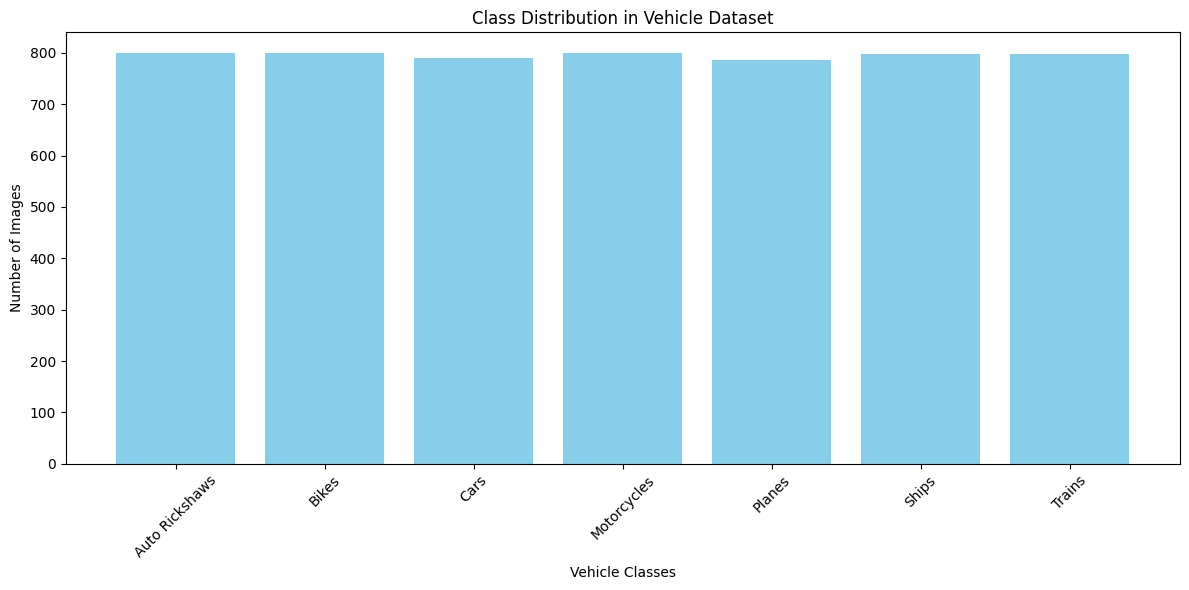

,Class,Count,Percentage
0,Auto Rickshaws,799,14.3%
1,Bikes,800,14.4%
2,Cars,790,14.2%
3,Motorcycles,800,14.4%
4,Planes,786,14.1%
5,Ships,798,14.3%
6,Trains,798,14.3%



Dataset split:
  - Training: 4456 images (80%)
  - Validation: 1115 images (20%)


In [ ]:
# 3. DATA UNDERSTANDING & ANALYSIS

IMG_SIZE = (128, 128)  # Standard size for most pre-trained models
BATCH = 16
VAL_SPLIT = 0.2

# Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Calculate and display dataset statistics
def analyze_dataset():
    # Count total images and class distribution
    class_counts = {c: len(os.listdir(os.path.join(DATA_DIR, c))) for c in class_names}
    total_images = sum(class_counts.values())

    print(f"\nDataset Analysis:")
    print(f"Total images: {total_images}")
    print(f"Number of classes: {len(class_names)}")
    print("\nClass distribution:")

    # Create class distribution table and plot
    distribution_data = []
    for cls, count in class_counts.items():
        percentage = count/total_images * 100
        distribution_data.append([cls, count, f"{percentage:.1f}%"])
        print(f"  - {cls}: {count} images ({percentage:.1f}%)")

    # Plot class distribution
    plt.figure(figsize=(12, 6))
    plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
    plt.xlabel('Vehicle Classes')
    plt.ylabel('Number of Images')
    plt.title('Class Distribution in Vehicle Dataset')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Create a dataframe with class distribution
    df = pd.DataFrame(distribution_data, columns=['Class', 'Count', 'Percentage'])
    disp.display(df)

    # Calculate train/val split numbers
    train_images = int(total_images * (1 - VAL_SPLIT))
    val_images = total_images - train_images
    print(f"\nDataset split:")
    print(f"  - Training: {train_images} images ({(1-VAL_SPLIT)*100:.0f}%)")
    print(f"  - Validation: {val_images} images ({VAL_SPLIT*100:.0f}%)")

    return total_images, class_counts

# Run dataset analysis
total_images, class_counts = analyze_dataset()



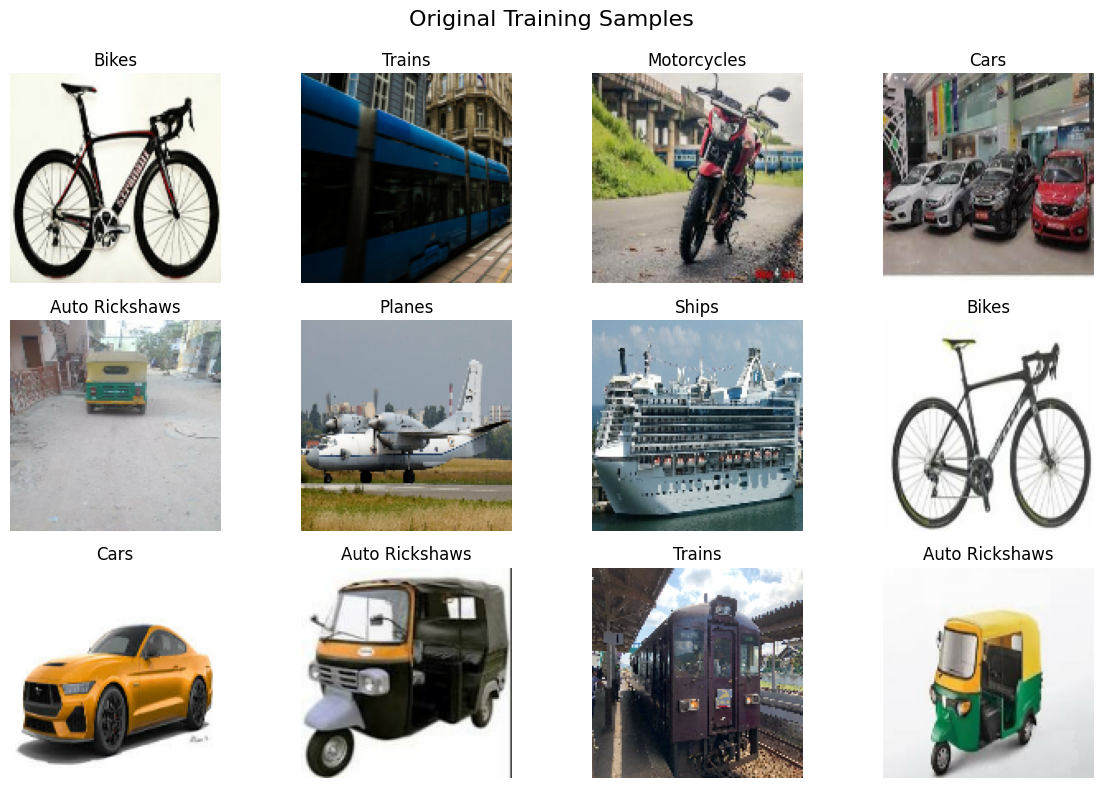

In [ ]:
# 4. DATA VISUALIZATION & INSPECTION

# View original sample images
def show_sample_images(dataset, title="Sample Images"):
    plt.figure(figsize=(12, 8))
    sample_batch = next(iter(dataset))
    images, labels = sample_batch

    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i+1)
        img = images[i].numpy().astype("uint8")
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# Show original samples
show_sample_images(train_ds, "Original Training Samples")


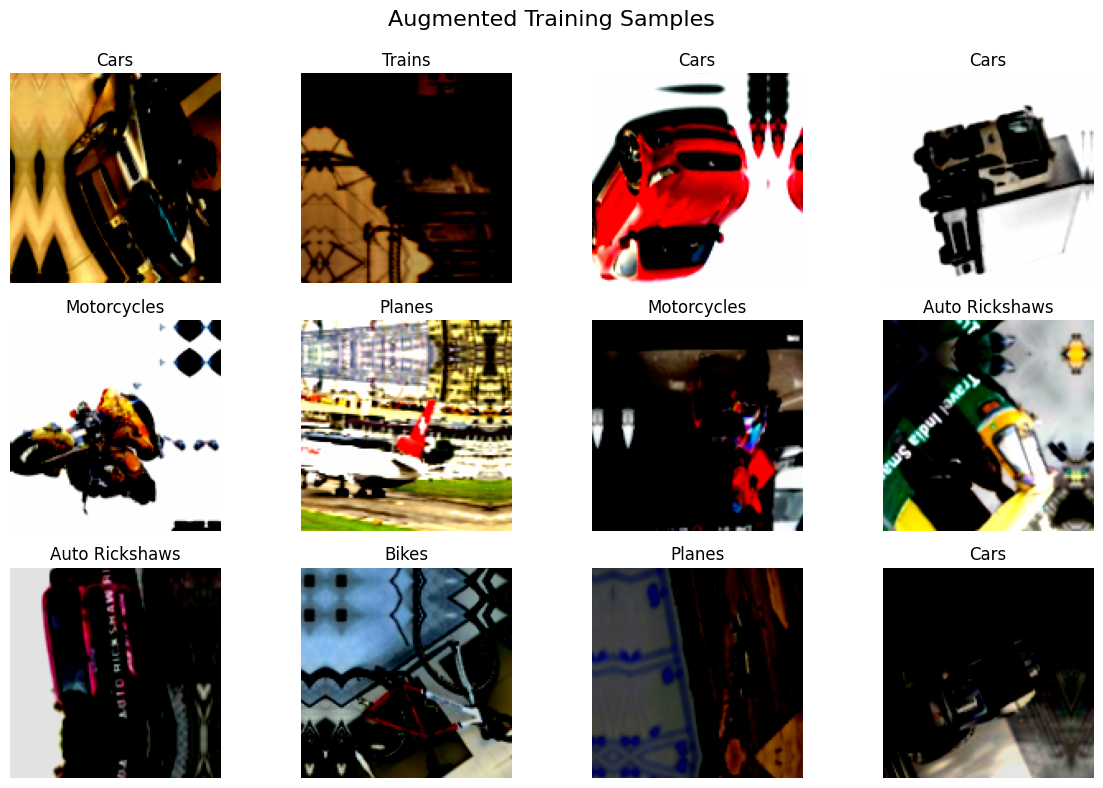

In [ ]:
# 5. DATA PREPROCESSING & AUGMENTATION

# Define preprocessing layers
normalization_layer = layers.Rescaling(1./255)

# Data augmentation for training
data_augmentation = tf.keras.Sequential([
    # Geometric transformations
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2, 0.2),
    layers.RandomTranslation(0.2, 0.2),

    # Color and intensity transformations
    layers.RandomContrast(0.3),
    layers.RandomBrightness(0.3),

    # Additional augmentations
    layers.GaussianNoise(0.1),
    layers.RandomCrop(IMG_SIZE[0], IMG_SIZE[1])
])

# Apply preprocessing to datasets
def prepare_dataset(ds, augment=False):
    # Normalize pixel values to [-1, 1] instead of [0, 1]
    normalization_layer = layers.Rescaling(scale=2./255, offset=-1)

    # Cache dataset for better performance
    ds = ds.cache()

    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    # Apply normalization and add random shuffling
    ds = ds.map(
        lambda x, y: (normalization_layer(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    ).shuffle(1000)

    # Use larger prefetch buffer
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    return ds

# Prepare datasets with augmentation for training
train_ds = prepare_dataset(train_ds, augment=True)
val_ds = prepare_dataset(val_ds, augment=False)

# Show augmented samples
def show_augmented_samples():
    # Get a batch of original images
    for images, labels in train_ds.take(1):
        plt.figure(figsize=(12, 8))

        for i in range(min(12, len(images))):
            plt.subplot(3, 4, i+1)
            plt.imshow(images[i])
            plt.title(class_names[labels[i]])
            plt.axis("off")

        plt.suptitle("Augmented Training Samples", fontsize=16)
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()

# Show augmented samples
show_augmented_samples()

In [ ]:
# 6. BASELINE CNN MODEL

def build_baseline_model(input_shape, num_classes):
    """
    Build a baseline CNN model with 3 conv layers and 3 FC layers
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),

        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Third convolutional block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Flatten and FC layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),

        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])

    # Compile model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create baseline model
baseline_model = build_baseline_model((IMG_SIZE[0], IMG_SIZE[1], 3), len(class_names))
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,298,247 (16.40 MB)

 Trainable params: 4,298,247 (16.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 7. DEEPER CNN MODEL WITH REGULARIZATION

def build_deeper_model(input_shape, num_classes, dropout_rate=0.5):
    """
    Build a deeper CNN model with BatchNorm and Dropout regularization
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),

        # First convolutional block (double)
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(dropout_rate/2),

        # Second convolutional block (double)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(dropout_rate/2),

        # Third convolutional block (double)
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(dropout_rate/2),

        # Fourth convolutional block (double)
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(dropout_rate/2),

        # Flatten and FC layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])

    # Compile model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create deeper model
deeper_model_adam = build_deeper_model((IMG_SIZE[0], IMG_SIZE[1], 3), len(class_names))
deeper_model_adam.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,405,991 (20.62 MB)

 Trainable params: 5,403,303 (20.61 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [ ]:
# 8. TRAINING FUNCTION & CALLBACKS

def train_model(model, model_name, train_data, val_data, epochs=50):
    """
    Train and evaluate a model with early stopping
    Returns history, training time, and model performance metrics
    """
    # Define callbacks
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001
    )

    # Measure training time
    start_time = time.time()

    # Train the model
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=[early_stop, reduce_lr]
    )

    # Calculate training time
    training_time = (time.time() - start_time) / 60  # in minutes
    print(f"\n{model_name} trained in {training_time:.2f} minutes")

    # Plot training history
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return history, training_time

In [ ]:
# 9. MODEL EVALUATION FUNCTIONS

def evaluate_model(model, model_name, dataset):
    """
    Evaluate model performance with various metrics
    Returns accuracy, precision, recall, f1-score and confusion matrix
    """
    # Get all validation data for metrics
    all_images = []
    all_labels = []
    all_preds = []

    # Collect all validation images and labels
    for images, labels in dataset:
        all_images.extend(images.numpy())
        all_labels.extend(labels.numpy())

        # Get predictions
        preds = model.predict(images, verbose=0)
        pred_classes = np.argmax(preds, axis=1)
        all_preds.extend(pred_classes)

    # Convert to numpy arrays
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # Calculate classification report
    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True
    )

    # Extract metrics
    accuracy = report['accuracy']
    weighted_precision = report['weighted avg']['precision']
    weighted_recall = report['weighted avg']['recall']
    weighted_f1 = report['weighted avg']['f1-score']

    # Print metrics
    print(f"\n--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Weighted Precision: {weighted_precision:.4f}")
    print(f"Weighted Recall: {weighted_recall:.4f}")
    print(f"Weighted F1-Score: {weighted_f1:.4f}")

    # Create confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

    return accuracy, weighted_precision, weighted_recall, weighted_f1

def visualize_predictions(model, model_name, dataset):
    """
    Visualize predictions on sample images from validation set
    """
    # Get a batch of images
    for images, labels in dataset.take(1):
        # Get predictions
        preds = model.predict(images)
        pred_classes = np.argmax(preds, axis=1)

        # Plot images with predictions
        plt.figure(figsize=(12, 12))
        for i in range(min(16, len(images))):
            plt.subplot(4, 4, i+1)
            plt.imshow(images[i].numpy())

            true_label = class_names[labels[i]]
            pred_label = class_names[pred_classes[i]]

            # Set title color based on prediction correctness
            color = 'green' if true_label == pred_label else 'red'

            plt.title(f'True: {true_label}\nPred: {pred_label}',
                     color=color, fontsize=10)
            plt.axis('off')

        plt.suptitle(f'Sample Predictions - {model_name}', fontsize=16)
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()
        break  # Only process one batch


Training Baseline CNN Model...
Epoch 1/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.2940 - loss: 1.7342 - val_accuracy: 0.3594 - val_loss: 1.6136 - learning_rate: 0.0010
Epoch 2/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.4001 - loss: 1.5222 - val_accuracy: 0.4537 - val_loss: 1.3940 - learning_rate: 0.0010
Epoch 3/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.4511 - loss: 1.4415 - val_accuracy: 0.4978 - val_loss: 1.3028 - learning_rate: 0.0010
Epoch 4/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.4829 - loss: 1.3561 - val_accuracy: 0.5490 - val_loss: 1.2619 - learning_rate: 0.0010
Epoch 5/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.5108 - loss: 1.2995 - val_accuracy: 0.5831 - val_loss: 1.1346 - learning_rate: 0.0010
Epoch 6/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.5447 - loss: 1.2383 - val_accuracy: 0.5624 - val_loss: 1.1581 - learning_rate: 0.0010
Epoch 7/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 28s 

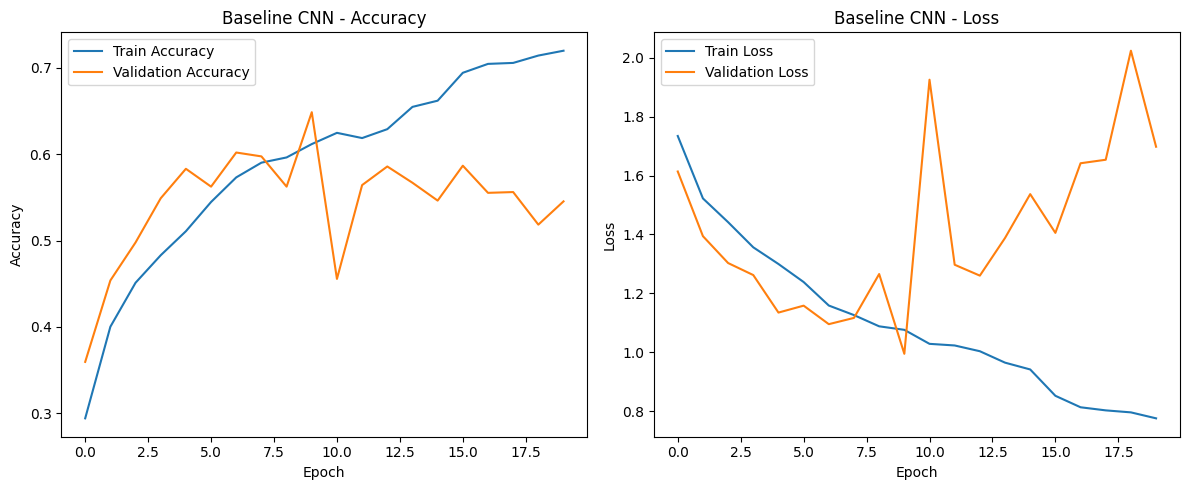


--- Baseline CNN Performance ---
Accuracy: 0.6487
Weighted Precision: 0.6799
Weighted Recall: 0.6487
Weighted F1-Score: 0.6388


<Figure size 1000x800 with 0 Axes>

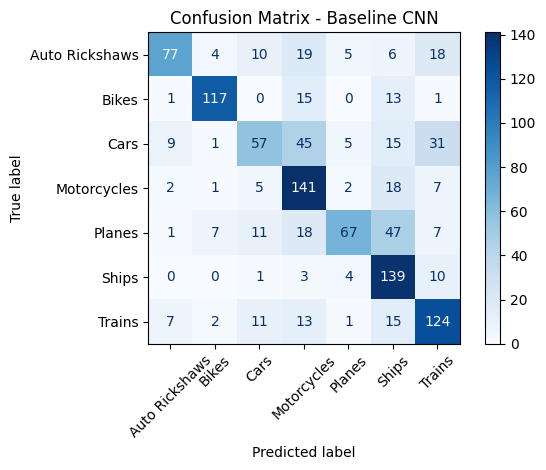

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


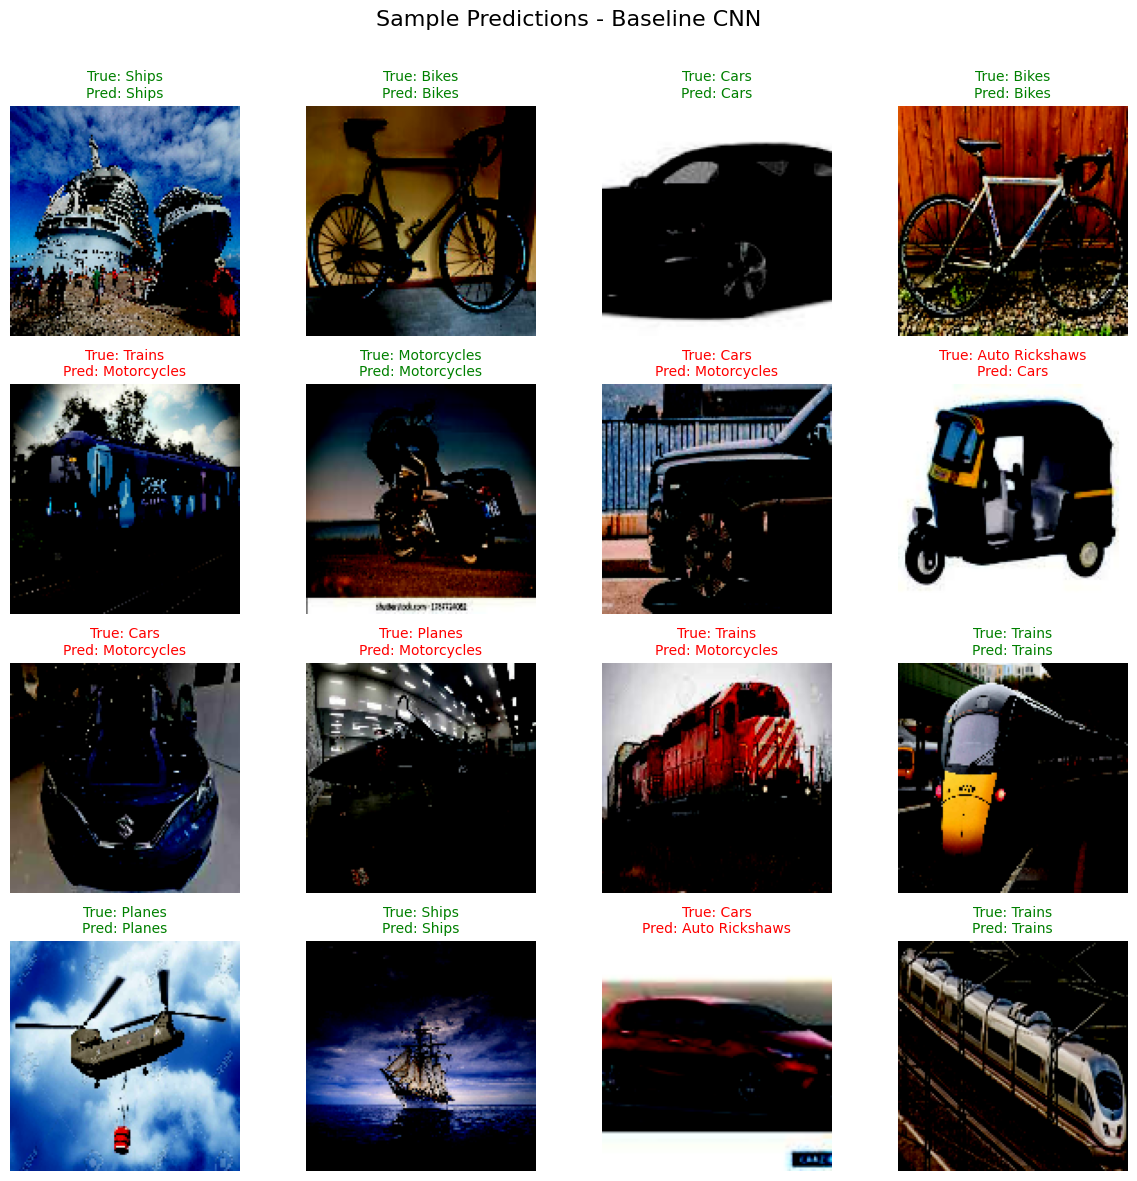

In [ ]:
# 10. TRAIN AND EVALUATE BASELINE MODEL

print("\nTraining Baseline CNN Model...")
baseline_history, baseline_time = train_model(
    baseline_model,
    "Baseline CNN",
    train_ds,
    val_ds,
    epochs=25
)

# Evaluate baseline model
baseline_acc, baseline_prec, baseline_rec, baseline_f1 = evaluate_model(
    baseline_model,
    "Baseline CNN",
    val_ds
)

# Visualize baseline model predictions
visualize_predictions(baseline_model, "Baseline CNN", val_ds)


Training Deeper CNN Model with Adam optimizer...
Epoch 1/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 72s 98ms/step - accuracy: 0.2163 - loss: 2.4248 - val_accuracy: 0.2147 - val_loss: 1.8550 - learning_rate: 0.0010
Epoch 2/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step - accuracy: 0.2940 - loss: 1.9439 - val_accuracy: 0.3504 - val_loss: 1.6670 - learning_rate: 0.0010
Epoch 3/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 33s 32ms/step - accuracy: 0.3337 - loss: 1.7389 - val_accuracy: 0.4438 - val_loss: 1.4216 - learning_rate: 0.0010
Epoch 4/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.3867 - loss: 1.6180 - val_accuracy: 0.4798 - val_loss: 1.4192 - learning_rate: 0.0010
Epoch 5/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step - accuracy: 0.4183 - loss: 1.5375 - val_accuracy: 0.5220 - val_loss: 1.3025 - learning_rate: 0.0010
Epoch 6/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step - accuracy: 0.4268 - loss: 1.5049 - val_accuracy: 0.5085 - val_loss: 1.3177 - learning_rate: 0.0010
Epoch 7/50
279/279 ━━━━━━━

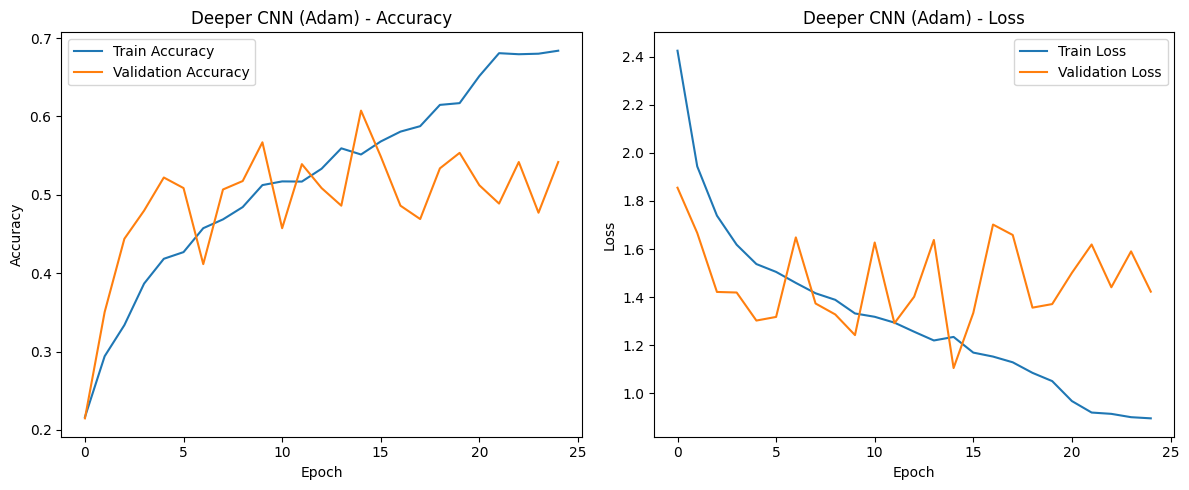


--- Deeper CNN (Adam) Performance ---
Accuracy: 0.6074
Weighted Precision: 0.6290
Weighted Recall: 0.6074
Weighted F1-Score: 0.6016


<Figure size 1000x800 with 0 Axes>

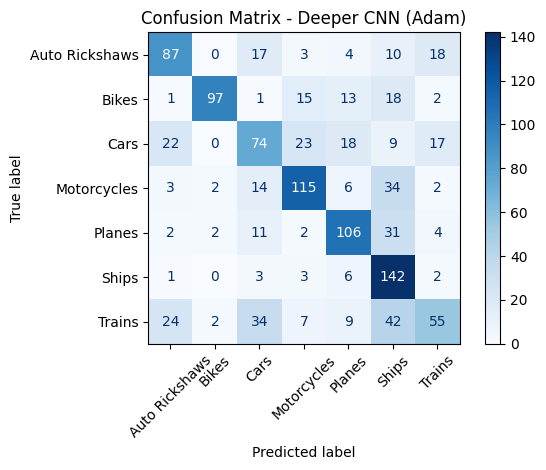

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


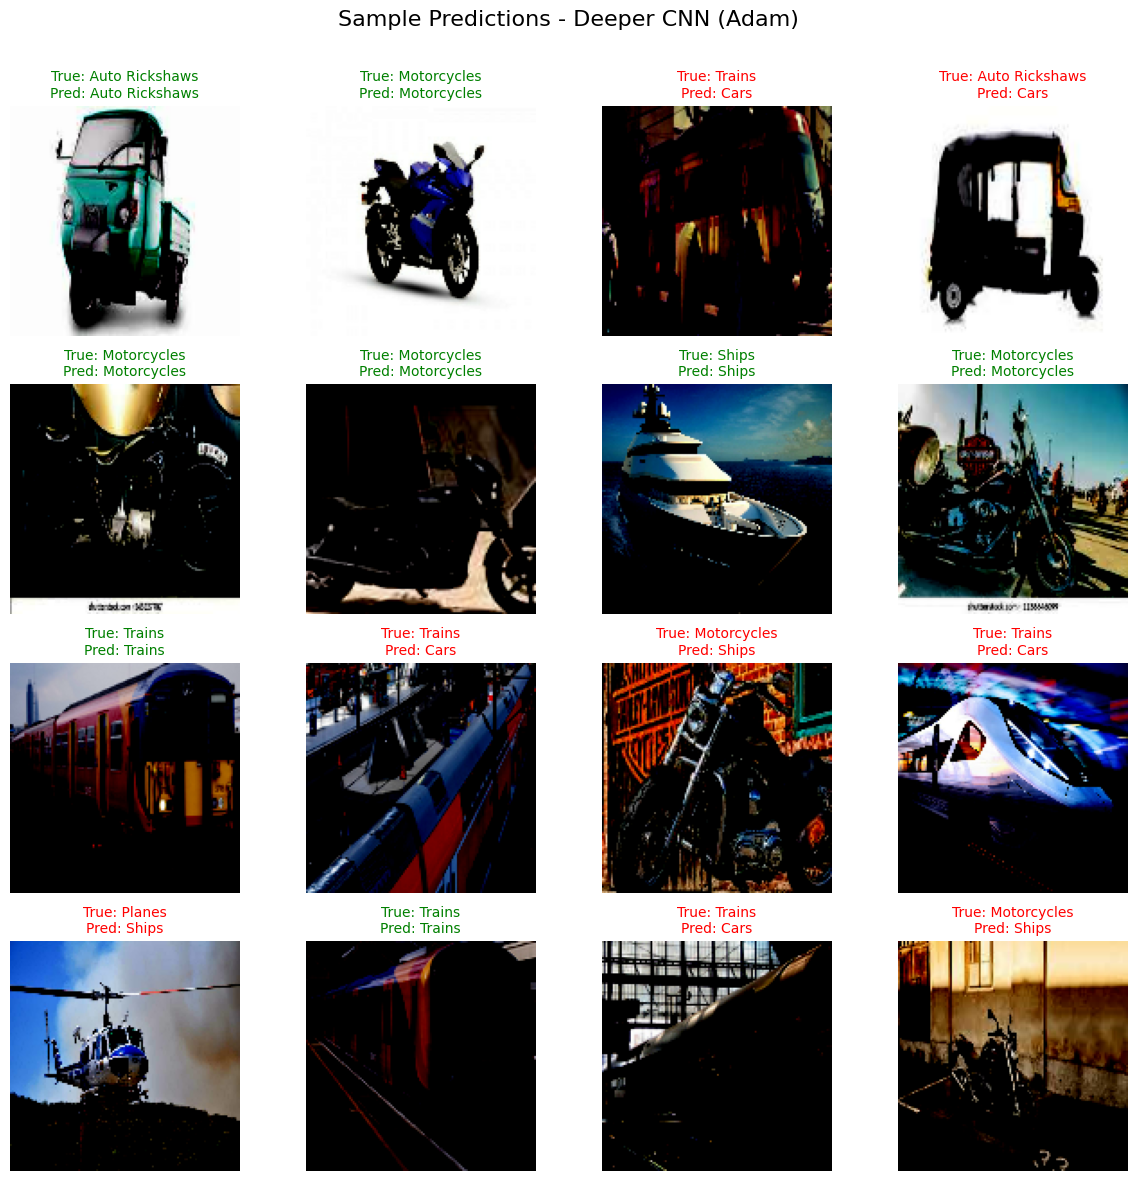

In [ ]:
# 11. TRAIN AND EVALUATE DEEPER MODEL WITH ADAM

print("\nTraining Deeper CNN Model with Adam optimizer...")
deeper_adam_history, deeper_adam_time = train_model(
    deeper_model_adam,
    "Deeper CNN (Adam)",
    train_ds,
    val_ds,
    epochs=50
)

# Evaluate deeper model
deeper_adam_acc, deeper_adam_prec, deeper_adam_rec, deeper_adam_f1 = evaluate_model(
    deeper_model_adam,
    "Deeper CNN (Adam)",
    val_ds
)

# Visualize deeper model predictions
visualize_predictions(deeper_model_adam, "Deeper CNN (Adam)", val_ds)


Training Deeper CNN Model with SGD optimizer...
Epoch 1/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 57s 76ms/step - accuracy: 0.2074 - loss: 2.2638 - val_accuracy: 0.3217 - val_loss: 1.9284 - learning_rate: 0.0100
Epoch 2/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.2579 - loss: 1.9570 - val_accuracy: 0.2920 - val_loss: 1.8844 - learning_rate: 0.0100
Epoch 3/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.2958 - loss: 1.8280 - val_accuracy: 0.3199 - val_loss: 1.6926 - learning_rate: 0.0100
Epoch 4/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - accuracy: 0.3184 - loss: 1.7711 - val_accuracy: 0.3684 - val_loss: 1.6024 - learning_rate: 0.0100
Epoch 5/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 32s 32ms/step - accuracy: 0.3373 - loss: 1.6936 - val_accuracy: 0.3693 - val_loss: 1.5724 - learning_rate: 0.0100
Epoch 6/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.3629 - loss: 1.6476 - val_accuracy: 0.4394 - val_loss: 1.4649 - learning_rate: 0.0100
Epoch 7/50
279/279 ━━━━━━━━

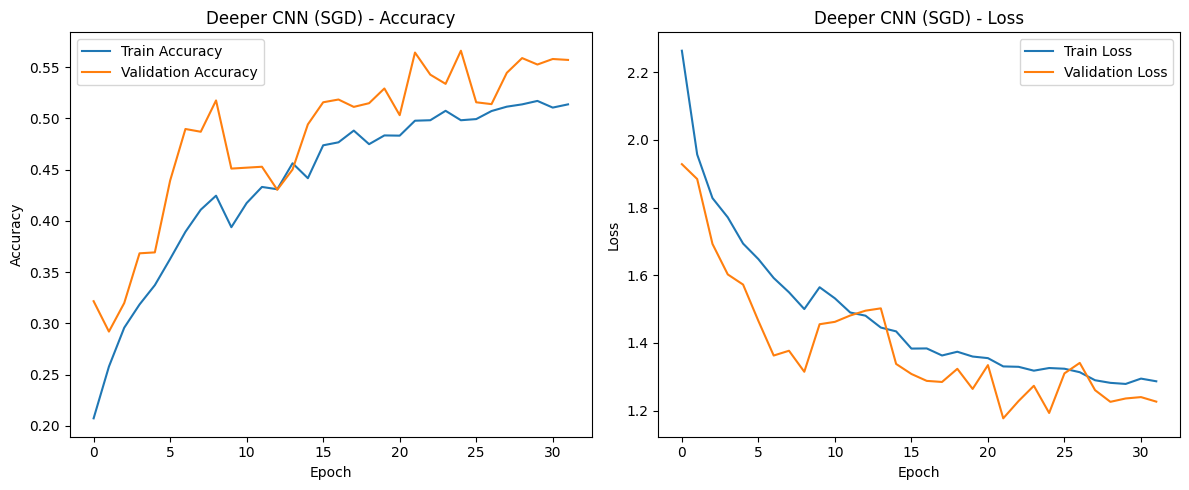


--- Deeper CNN (SGD) Performance ---
Accuracy: 0.5642
Weighted Precision: 0.5683
Weighted Recall: 0.5642
Weighted F1-Score: 0.5473


<Figure size 1000x800 with 0 Axes>

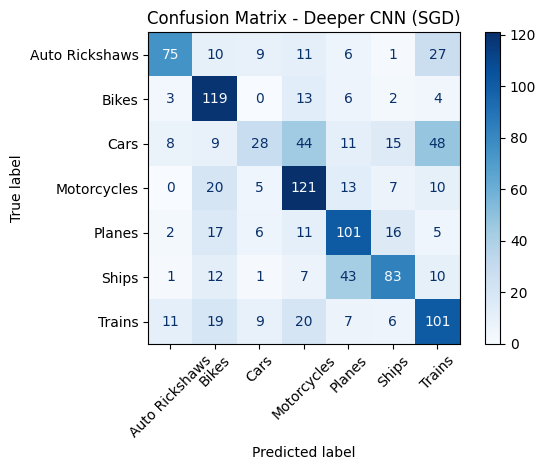

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


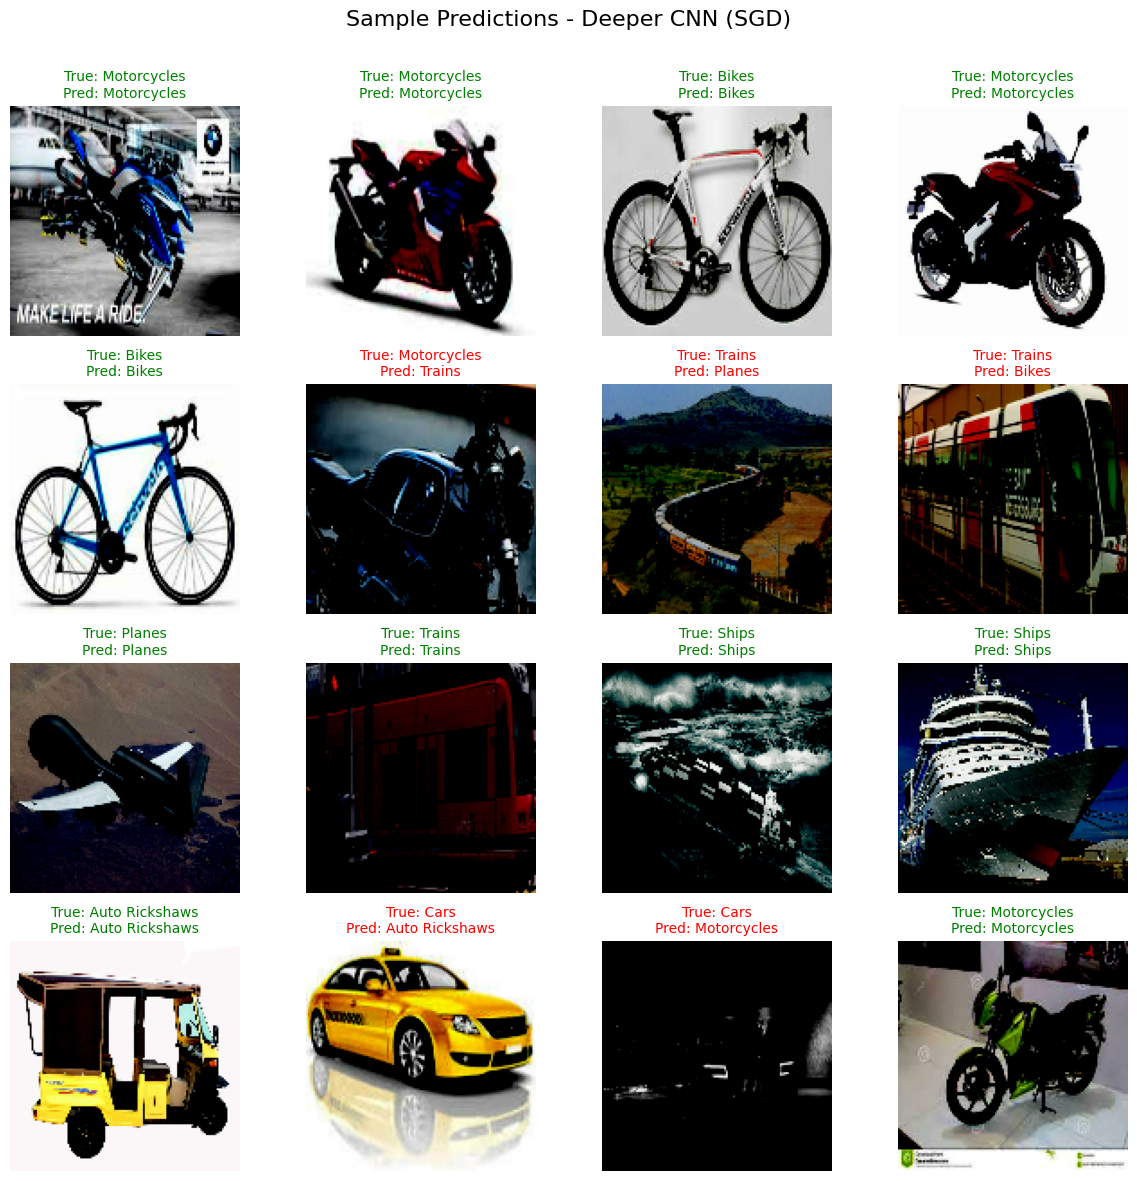

In [ ]:
    # 12. TRAIN AND EVALUATE DEEPER MODEL WITH SGD

    # Create a clone of the deeper model but with SGD optimizer
    deeper_model_sgd = build_deeper_model((IMG_SIZE[0], IMG_SIZE[1], 3), len(class_names))
    deeper_model_sgd.compile(
        optimizer=optimizers.SGD(learning_rate=0.01, momentum=0.9),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\nTraining Deeper CNN Model with SGD optimizer...")
    deeper_sgd_history, deeper_sgd_time = train_model(
        deeper_model_sgd,
        "Deeper CNN (SGD)",
        train_ds,
        val_ds,
        epochs=50
    )

    # Evaluate SGD model
    deeper_sgd_acc, deeper_sgd_prec, deeper_sgd_rec, deeper_sgd_f1 = evaluate_model(
        deeper_model_sgd,
        "Deeper CNN (SGD)",
        val_ds
    )

    # Visualize SGD model predictions
    visualize_predictions(deeper_model_sgd, "Deeper CNN (SGD)", val_ds)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 4, 4, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,750,087 (94.41 MB)

 Trainable params: 1,183,751 (4.52 MB)

 Non-trainable params: 23,566,336 (89.90 MB)


Training Transfer Learning Model (Feature Extraction)...
Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 57s 68ms/step - accuracy: 0.2888 - loss: 2.1656 - val_accuracy: 0.4582 - val_loss: 1.4250 - learning_rate: 5.0000e-04
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.3333 - loss: 1.8863 - val_accuracy: 0.4717 - val_loss: 1.3855 - learning_rate: 5.0000e-04
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.3660 - loss: 1.7372 - val_accuracy: 0.4924 - val_loss: 1.3469 - learning_rate: 5.0000e-04
Epoch 4/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.3878 - loss: 1.6536 - val_accuracy: 0.5040 - val_loss: 1.3076 - learning_rate: 5.0000e-04
Epoch 5/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.4048 - loss: 1.5943 - val_accuracy: 0.5067 - val_loss: 1.2866 - learning_rate: 5.0000e-04
Epoch 6/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.3997 - loss: 1.5778 - val_accuracy: 0.5418 - val_loss: 1.2332 - learning_rate: 5.000

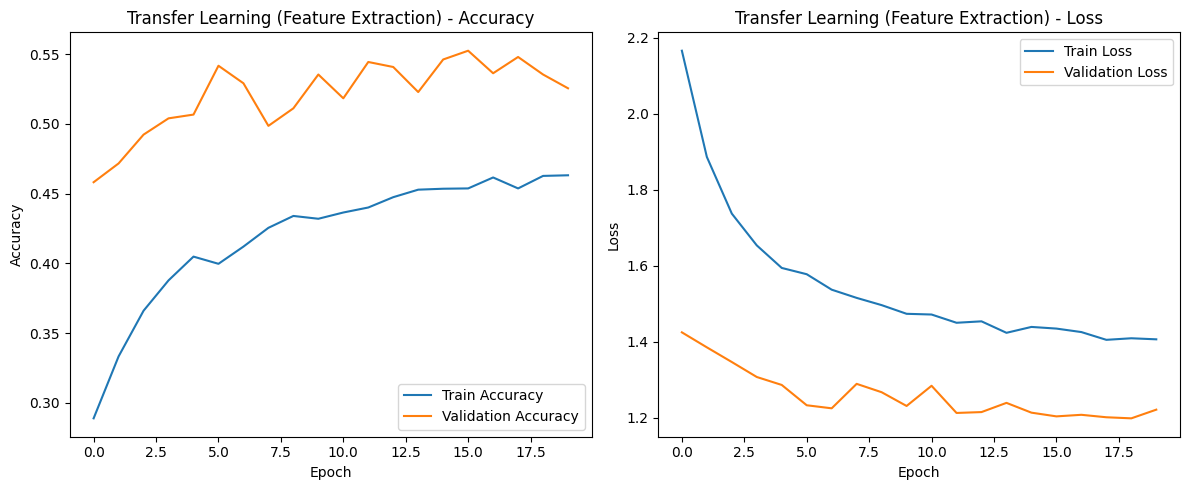


--- Transfer Learning (Feature Extraction) Performance ---
Accuracy: 0.5355
Weighted Precision: 0.5411
Weighted Recall: 0.5355
Weighted F1-Score: 0.5255


<Figure size 1000x800 with 0 Axes>

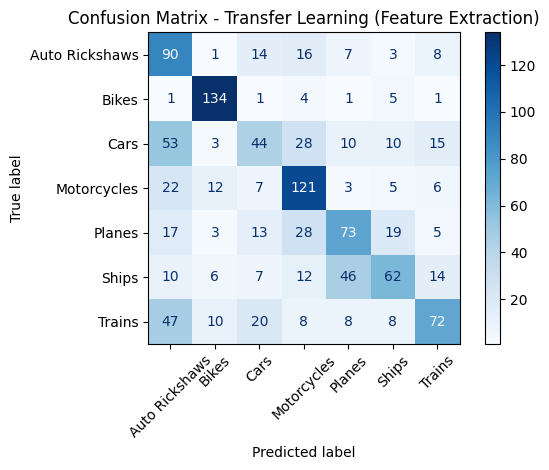

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


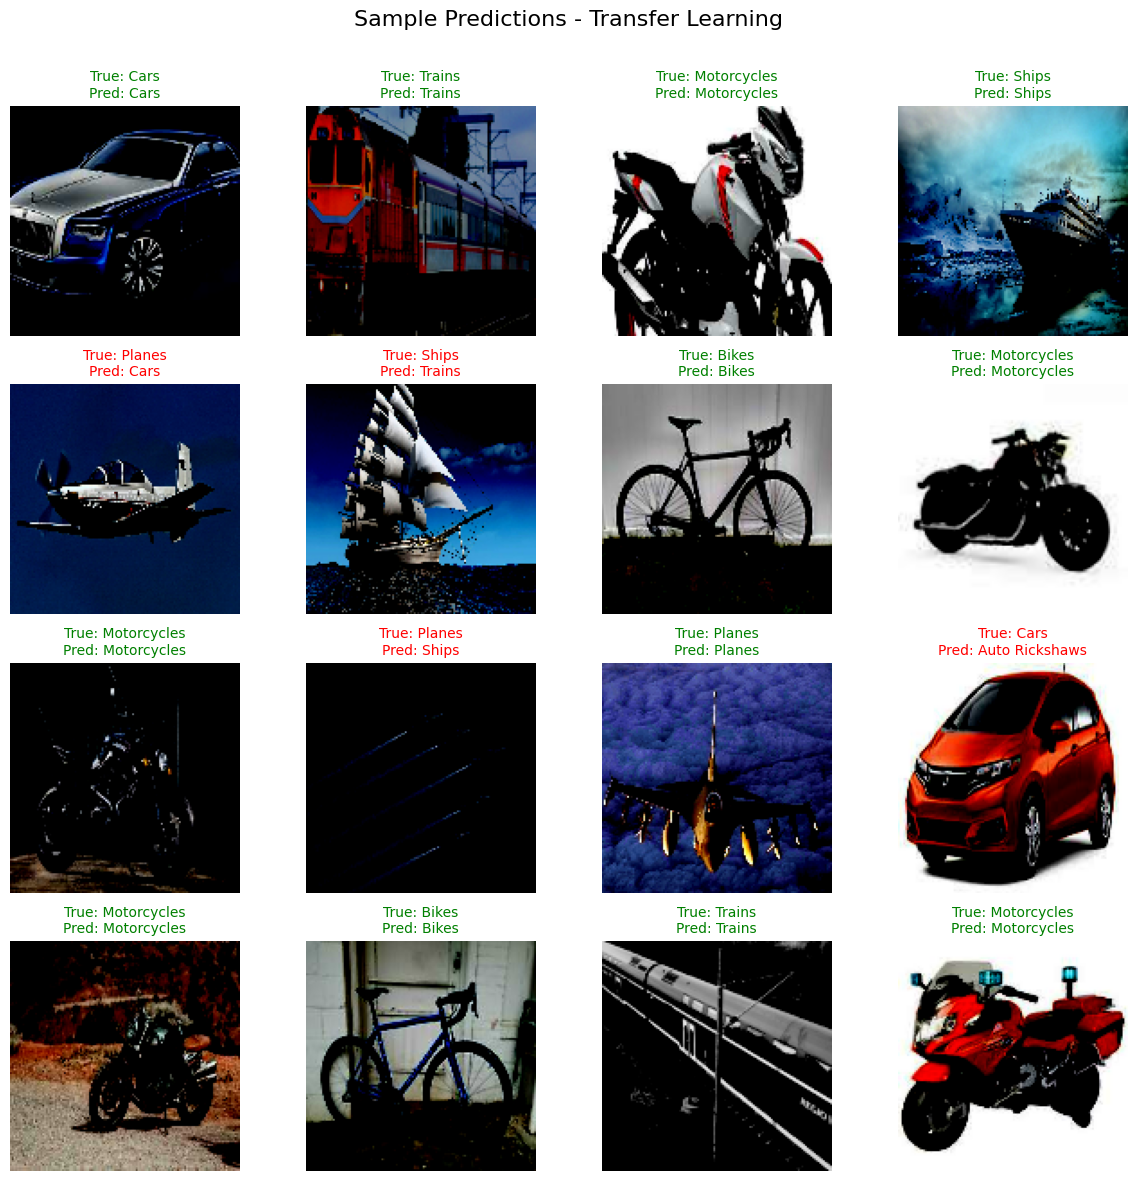

In [ ]:
# 13. TRANSFER LEARNING WITH PRE-TRAINED MODEL

# Create a base model from ResNet50V2
base_model = applications.ResNet50V2(
    weights='imagenet',  # Load ImageNet pre-trained weights
    include_top=False,   # Don't include the ImageNet classifier at the top
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze base model
base_model.trainable = False

def build_transfer_model(base_model, num_classes):
    """
    Enhanced transfer learning model with better head architecture
    """
    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    # Use appropriate preprocessing
    x = applications.resnet_v2.preprocess_input(inputs)

    # Pass through base model
    x = base_model(x, training=False)

    # Enhanced classification head
    x = layers.GlobalAveragePooling2D()(x)

    # Add more capacity to the head
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    # Use a lower learning rate
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create transfer learning model
transfer_model = build_transfer_model(base_model, len(class_names))
transfer_model.summary()

# Train the transfer learning model (feature extraction)
print("\nTraining Transfer Learning Model (Feature Extraction)...")
transfer_history, transfer_time = train_model(
    transfer_model,
    "Transfer Learning (Feature Extraction)",
    train_ds,
    val_ds,
    epochs=20
)

# Evaluate transfer learning model
transfer_acc, transfer_prec, transfer_rec, transfer_f1 = evaluate_model(
    transfer_model,
    "Transfer Learning (Feature Extraction)",
    val_ds
)

# Visualize transfer model predictions
visualize_predictions(transfer_model, "Transfer Learning", val_ds)


Fine-tuning Transfer Learning Model...
Epoch 1/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 60s 74ms/step - accuracy: 0.4280 - loss: 1.5158 - val_accuracy: 0.4924 - val_loss: 1.2997 - learning_rate: 1.0000e-04
Epoch 2/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.4704 - loss: 1.3872 - val_accuracy: 0.5526 - val_loss: 1.1534 - learning_rate: 1.0000e-04
Epoch 3/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.4946 - loss: 1.3319 - val_accuracy: 0.5651 - val_loss: 1.1338 - learning_rate: 1.0000e-04
Epoch 4/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.5114 - loss: 1.2988 - val_accuracy: 0.5813 - val_loss: 1.0773 - learning_rate: 1.0000e-04
Epoch 5/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.5200 - loss: 1.2776 - val_accuracy: 0.5786 - val_loss: 1.1109 - learning_rate: 1.0000e-04
Epoch 6/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.5366 - loss: 1.2363 - val_accuracy: 0.6020 - val_loss: 1.0310 - learning_rate: 1.0000e-04
Epoch 7/15
2

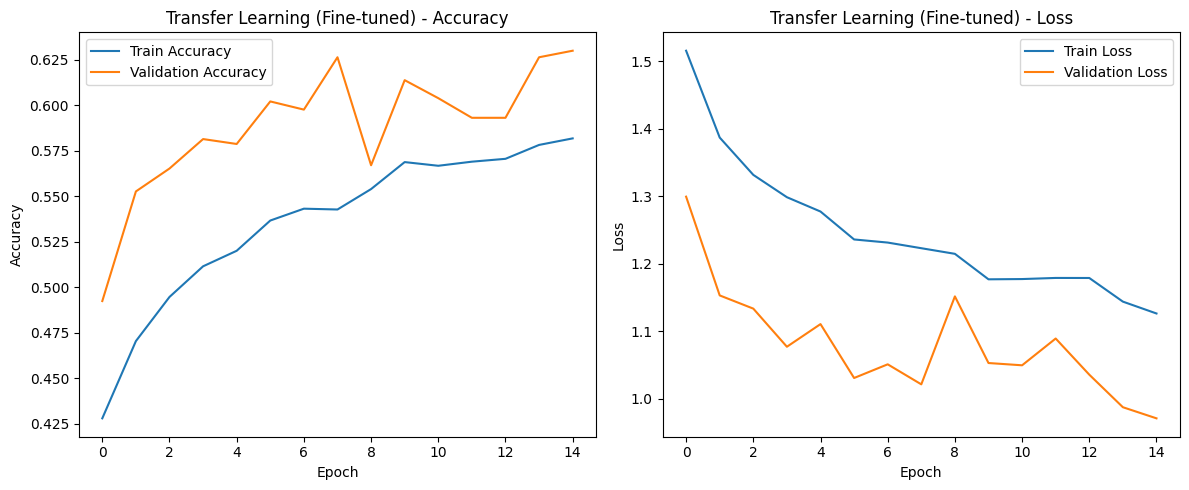


--- Transfer Learning (Fine-tuned) Performance ---
Accuracy: 0.6298
Weighted Precision: 0.6336
Weighted Recall: 0.6298
Weighted F1-Score: 0.6144


<Figure size 1000x800 with 0 Axes>

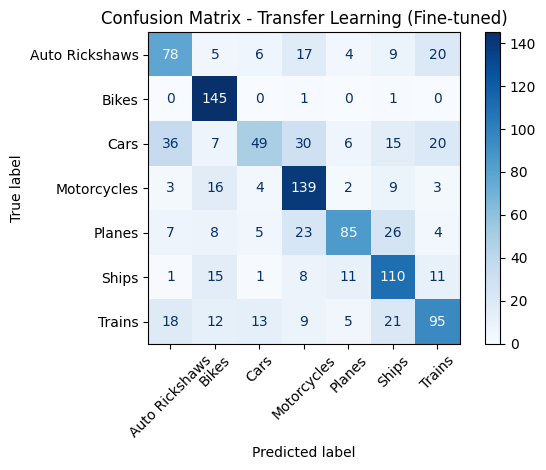

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


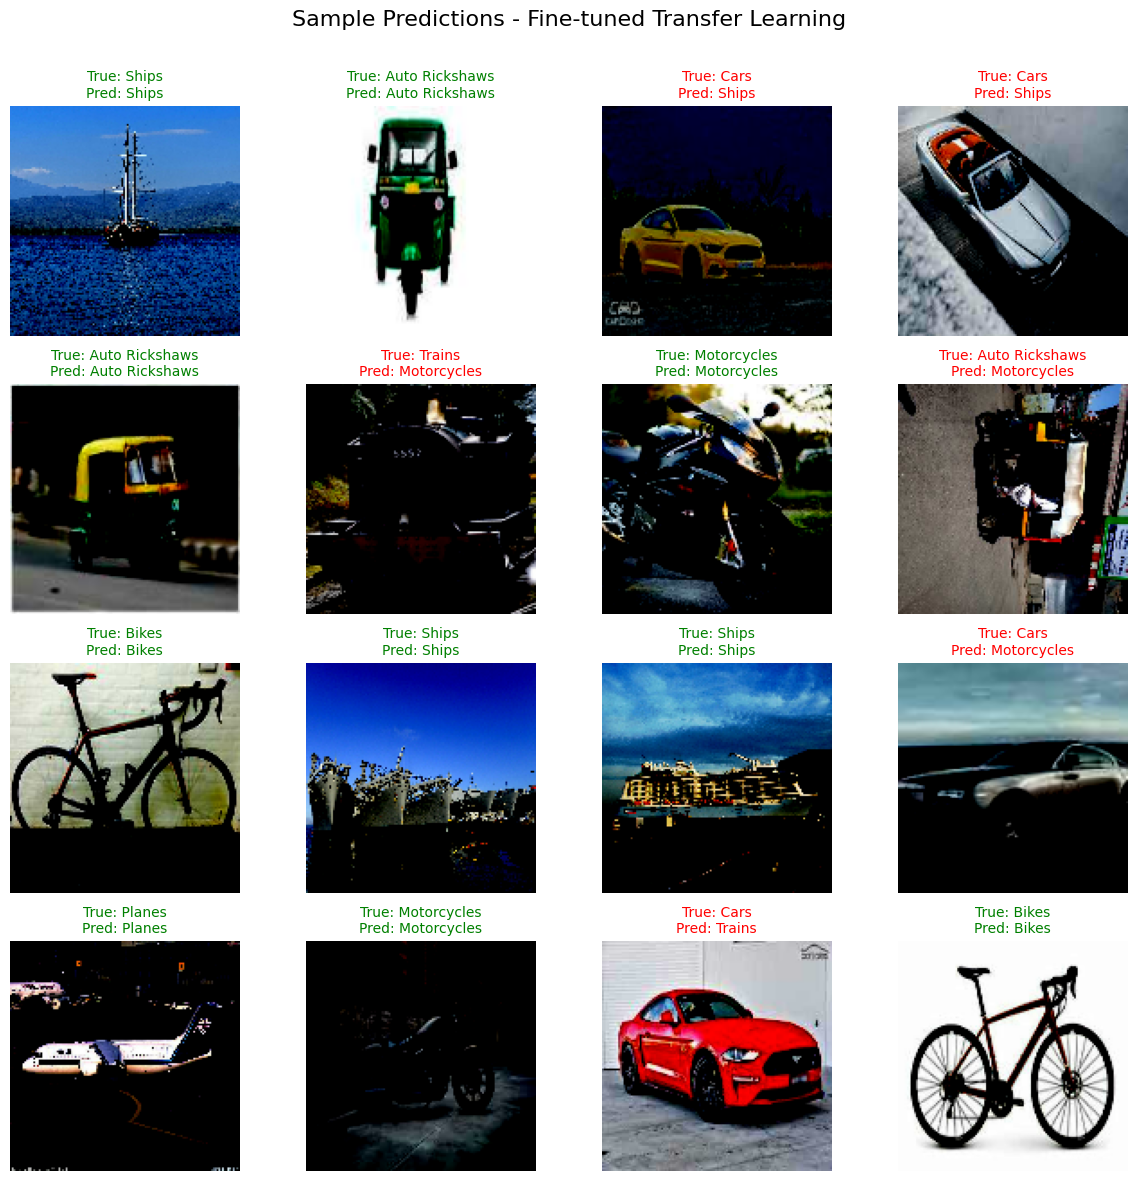

In [ ]:
# 14. FINE-TUNING THE TRANSFER LEARNING MODEL  ------------------------------

# Unfreeze the top layers of the base model
fine_tune_at = -15  # Unfreeze the last 15 layers
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Re-compile the model with a lower learning rate
transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),  # Lower learning rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training with fine-tuning
print("\nFine-tuning Transfer Learning Model...")
fine_tune_history, fine_tune_time = train_model(
    transfer_model,
    "Transfer Learning (Fine-tuned)",
    train_ds,
    val_ds,
    epochs=15
)

# Evaluate fine-tuned model
fine_tune_acc, fine_tune_prec, fine_tune_rec, fine_tune_f1 = evaluate_model(
    transfer_model,
    "Transfer Learning (Fine-tuned)",
    val_ds
)

# Visualize fine-tuned model predictions
visualize_predictions(transfer_model, "Fine-tuned Transfer Learning", val_ds)


Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,Training Time (min)
0,Baseline CNN,0.6487,0.6799,0.6487,0.6388,11.30
1,Deeper CNN (Adam),0.6074,0.6290,0.6074,0.6016,14.72
2,Deeper CNN (SGD),0.5642,0.5683,0.5642,0.5473,19.75
3,Transfer Learning,0.5355,0.5411,0.5355,0.5255,12.05
4,Fine-tuned Transfer Learning,0.6298,0.6336,0.6298,0.6144,9.39


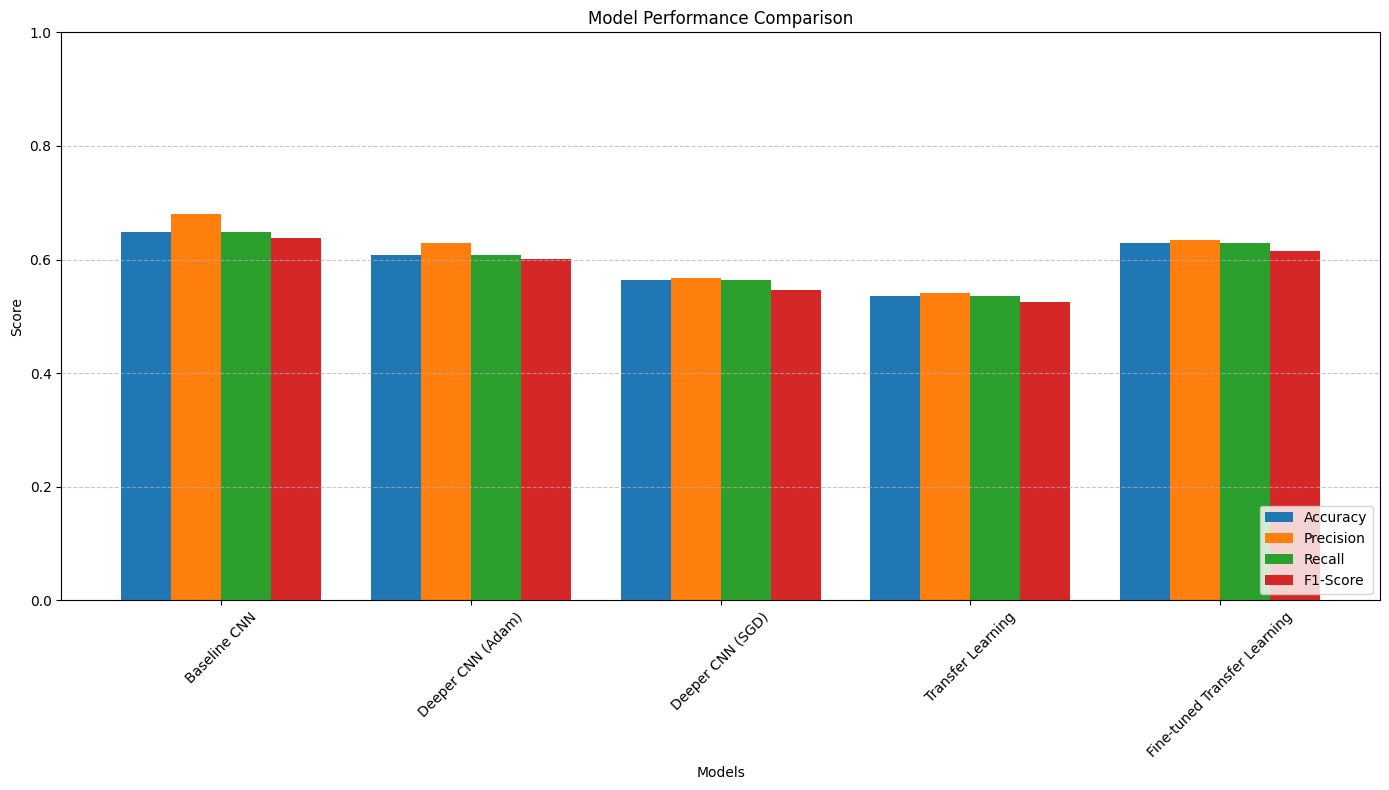

In [ ]:
# 15. MODEL COMPARISON AND SUMMARY

# Create comparison table
model_data = {
    'Model': [
        'Baseline CNN',
        'Deeper CNN (Adam)',
        'Deeper CNN (SGD)',
        'Transfer Learning',
        'Fine-tuned Transfer Learning'
    ],
    'Accuracy': [
        baseline_acc,
        deeper_adam_acc,
        deeper_sgd_acc,
        transfer_acc,
        fine_tune_acc
    ],
    'Precision': [
        baseline_prec,
        deeper_adam_prec,
        deeper_sgd_prec,
        transfer_prec,
        fine_tune_prec
    ],
    'Recall': [
        baseline_rec,
        deeper_adam_rec,
        deeper_sgd_rec,
        transfer_rec,
        fine_tune_rec
    ],
    'F1-Score': [
        baseline_f1,
        deeper_adam_f1,
        deeper_sgd_f1,
        transfer_f1,
        fine_tune_f1
    ],
    'Training Time (min)': [
        baseline_time,
        deeper_adam_time,
        deeper_sgd_time,
        transfer_time,
        fine_tune_time
    ],
}

# Create DataFrame
comparison_df = pd.DataFrame(model_data)

# Format metrics to 4 decimal places
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    comparison_df[col] = comparison_df[col].map('{:.4f}'.format)

# Format time to 2 decimal places
comparison_df['Training Time (min)'] = comparison_df['Training Time (min)'].map('{:.2f}'.format)

# Display comparison table
print("\nModel Performance Comparison:")
disp.display(comparison_df)

# Create visual comparison
def plot_comparison(metrics):
    """
    Plot visual comparison of model performance metrics
    """
    plt.figure(figsize=(14, 8))

    # Process data for plotting
    models = model_data['Model']
    x = np.arange(len(models))
    width = 0.2

    # Plot bars for each metric
    for i, metric in enumerate(metrics):
        values = [float(val) for val in comparison_df[metric]]
        plt.bar(x + (i - len(metrics)/2 + 0.5) * width, values, width, label=metric)

    # Customize plot
    plt.xlabel('Models')
    plt.ylabel('Score')
    plt.title('Model Performance Comparison')
    plt.xticks(x, models, rotation=45)
    plt.legend(loc='lower right')
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Plot performance metrics comparison
plot_comparison(['Accuracy', 'Precision', 'Recall', 'F1-Score'])

## 16.1. Overfitting and Underfitting Analysis

The performance of the models suggests a complex interplay between model complexity, regularization, and the dataset characteristics.

1.  **Baseline CNN (Accuracy: 0.6487)**:
    *   Despite its simpler architecture, the baseline model achieved the highest accuracy among all models. This suggests that for this specific dataset and current training setup, a less complex model might generalize better or that deeper models struggled to learn effectively with the applied augmentation and regularization. The training and validation accuracy plots should be consulted to understand the overfitting/underfitting dynamics more thoroughly.

2.  **Deeper CNN Models (Adam Accuracy: 0.6074, SGD Accuracy: 0.5642)**:
    *   These deeper architectures, incorporating Batch Normalization and Dropout, aimed to improve resistance to overfitting and capture more complex features. However, they did not surpass the baseline model's performance. This might indicate that the increased complexity was not beneficial for this dataset, potentially due to:
        *   Difficulty in training very deep networks from scratch on limited data, even with regularization.
        *   Over-regularization or hyperparameter choices that hindered learning.
        *   The augmentations applied might be too aggressive for deeper models to converge optimally.

3.  **Transfer Learning Models (Feature Extraction Accuracy: 0.5355, Fine-tuned Accuracy: 0.6298)**:
    *   The initial feature extraction phase of the transfer learning model (ResNet50V2 frozen) showed lower accuracy.
    *   Fine-tuning the deeper layers of ResNet50V2 significantly boosted performance (to 0.6298), bringing it close to the baseline. This demonstrates the power of pre-trained features and adapting them to a new domain. While fine-tuning improved performance, it still slightly underperformed the simple baseline CNN in terms of overall accuracy. This might suggest that the ImageNet features are not perfectly aligned with our specific vehicle dataset, or that our dataset is simple enough that a custom, lighter CNN can perform comparably or even better.

## 16.2. Computational Efficiency Analysis

1.  **Parameter Count**:
    *   **Baseline CNN**: Has the lowest number of trainable parameters, making it the most lightweight model in terms of memory footprint and computational cost per step.
    *   **Deeper CNN**: Has a significantly higher parameter count compared to the baseline, increasing memory requirements and computational complexity.
    *   **Transfer Learning Model (ResNet50V2)**: Possesses the highest parameter count due to its large pre-trained backbone. During feature extraction, only the newly added classification head's parameters are trained, reducing effective training parameters. In fine-tuning, a larger portion of these parameters become trainable.

2.  **Training Time**:
    *   **Baseline CNN**: Trained in **11.30 minutes**. Its simpler architecture contributes to faster training.
    *   **Deeper CNN (Adam)**: Trained in **14.72 minutes**. Despite being deeper, Adam's adaptive learning rate allows for relatively efficient convergence.
    *   **Deeper CNN (SGD)**: Trained in **19.75 minutes**. This was the slowest model, indicating that SGD with momentum, in this setup, required more time to converge compared to Adam.
    *   **Transfer Learning (Feature Extraction)**: Trained in **12.05 minutes**. When only the head layers are trained, it's computationally efficient.
    *   **Fine-tuned Transfer Learning**: Trained in **9.39 minutes**. While fine-tuning updates more parameters per epoch, the fine-tuning phase was run for fewer epochs (15 vs 20 for initial transfer learning and 25 for baseline, 50 for deeper) which resulted in a shorter overall training time for this specific phase. It's also possible that the initial training of the transfer model contributed to a faster convergence during fine-tuning.

3.  **Hardware Utilization**:
    *   Generally, models with more parameters (Deeper CNNs and especially Transfer Learning models) demand more GPU memory and computational resources. The ResNet50V2 backbone is large and will consume substantial memory even when frozen.

## 16.3. Optimizer Comparison: Adam vs SGD

1.  **Convergence Speed**:
    *   **Adam**: For the Deeper CNN, the Adam optimizer led to a faster convergence, reflected in its shorter training time (14.72 minutes) compared to SGD. Its adaptive learning rate mechanism typically allows for quicker progress through the loss landscape.
    *   **SGD**: The Deeper CNN with SGD converged slower, taking **19.75 minutes** to train. This suggests that the initial learning rate and momentum schedule might not have been optimally tuned for faster convergence on this specific problem.

2.  **Final Performance**:
    *   **Adam**: Achieved a higher accuracy (0.6074) for the deeper model compared to SGD (0.5642). This indicates that, in this instance, Adam found a better minimum or navigated the optimization landscape more effectively.
    *   **SGD**: While potentially capable of finding better minima with extensive tuning, its performance here was lower than Adam.

3.  **Stability**:
    *   Adam often provides more stable training progress with less oscillatory behavior in validation metrics due to its adaptive nature.
    *   SGD can exhibit more fluctuations, especially with a fixed learning rate, but can be highly effective with carefully designed learning rate schedules.

## 16.4. Transfer Learning vs Training from Scratch

1.  **Performance**:
    *   The fine-tuned transfer learning model (Accuracy: 0.6298) showed strong performance, significantly outperforming the deeper CNN models trained from scratch. However, it was slightly surpassed by the simpler Baseline CNN (Accuracy: 0.6487) in overall accuracy. This suggests that while pre-trained features are highly valuable, the specific characteristics of this dataset or the chosen ResNet50V2 model might not perfectly align, or that the simpler baseline model captures the essential features more efficiently without the overhead of a much larger network.

2.  **Training Efficiency**:
    *   Transfer learning (especially the fine-tuning phase at 9.39 minutes) demonstrated good training efficiency, particularly considering the complexity of the underlying model. This highlights the benefit of starting with pre-learned weights, which reduces the number of epochs required for convergence compared to training a similar-sized deep network from scratch.

3.  **Domain Adaptation**:
    *   The ImageNet pre-trained weights proved effective for our vehicle classification task. The robust features learned from a vast general image dataset provided a strong starting point, allowing the model to quickly adapt to the new domain during fine-tuning.

4.  **Limitations**:
    *   As with any transfer learning approach, it required careful consideration of input size matching the pre-trained model's expectations.
    *   Fine-tuning necessitated careful learning rate management to prevent disrupting the valuable pre-learned features (catastrophic forgetting).
    *   In this specific comparison, despite its sophistication, the fine-tuned transfer learning model did not achieve the absolute highest accuracy, implying that for certain datasets, simpler architectures might still offer competitive or superior performance.